In [38]:
from utility.retrieve_desi_spectra import retrieve_desi_spectra
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift

from polars import read_json

In [26]:
query = """
        SELECT zp.targetid, zp.survey, zp.program, zp.desi_target, zp.z, zp.zwarn, zp.spectype
        FROM desi_dr1.zpix as zp
        WHERE (zp.survey='main') AND zp.main_primary AND (zp.z BETWEEN 2 AND 3.4) AND (zp.zwarn=0)
        LIMIT 3000
        """

#zp.targetid, zp.survey, zp.program, zp.desi_target, zp.z, zp.zwarn, zp.spectype        
# (zp.random_id BETWEEN 13 AND 23)

output_fields = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary','survey', 'data_release', 'targetid', 'redshift_warning', 'desi_target']

# target_mask = ["QSO"]

In [ ]:
# spectra = retrieve_desi_spectra(query, output_fields)

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


In [ ]:
# spectra.write_json("data/random_sample.json")
spectra = read_json("data/random_sample.json")

In [43]:
spectra

specprimary,targetid,redshift,spectype,redshift_warning,data_release,specid,desi_target,survey,flux,wavelength,_dr
bool,i64,f64,str,i64,str,i64,i64,str,list[f64],list[f64],str
true,39627603681743306,2.002515,"""QSO""",0,"""DESI-DR1""",39627603681743306,917542,"""main""","[2.016706, 3.277092, … 0.294488]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
true,39627836255897213,2.003613,"""QSO""",0,"""DESI-DR1""",39627836255897213,6917529027641344004,"""main""","[70.843102, 74.107651, … 8.041104]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
true,39628523048014543,2.002435,"""QSO""",0,"""DESI-DR1""",39628523048014543,917542,"""main""","[3.041712, -3.847298, … -0.231769]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
true,39627895886316396,2.001214,"""QSO""",0,"""DESI-DR1""",39627895886316396,4611686018428305446,"""main""","[9.33099, 5.215515, … 1.275409]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
true,39628190380985224,2.000349,"""QSO""",0,"""DESI-DR1""",39628190380985224,4611686018427650052,"""main""","[26.169754, 14.898165, … 1.952054]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
…,…,…,…,…,…,…,…,…,…,…,…
true,39627815615728372,2.000091,"""QSO""",0,"""DESI-DR1""",39627815615728372,4611686018428305446,"""main""","[-3.720573, 2.27893, … 0.182972]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
true,39627809668204987,2.00117,"""QSO""",0,"""DESI-DR1""",39627809668204987,4611686018427650052,"""main""","[11.122598, 7.885783, … 1.682113]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""
true,39627640964908243,2.002212,"""QSO""",0,"""DESI-DR1""",39627640964908243,4611686018428305446,"""main""","[7.503693, 2.176657, … 0.263302]","[3600.0, 3600.8, … 9824.0]","""DESI-DR1"""


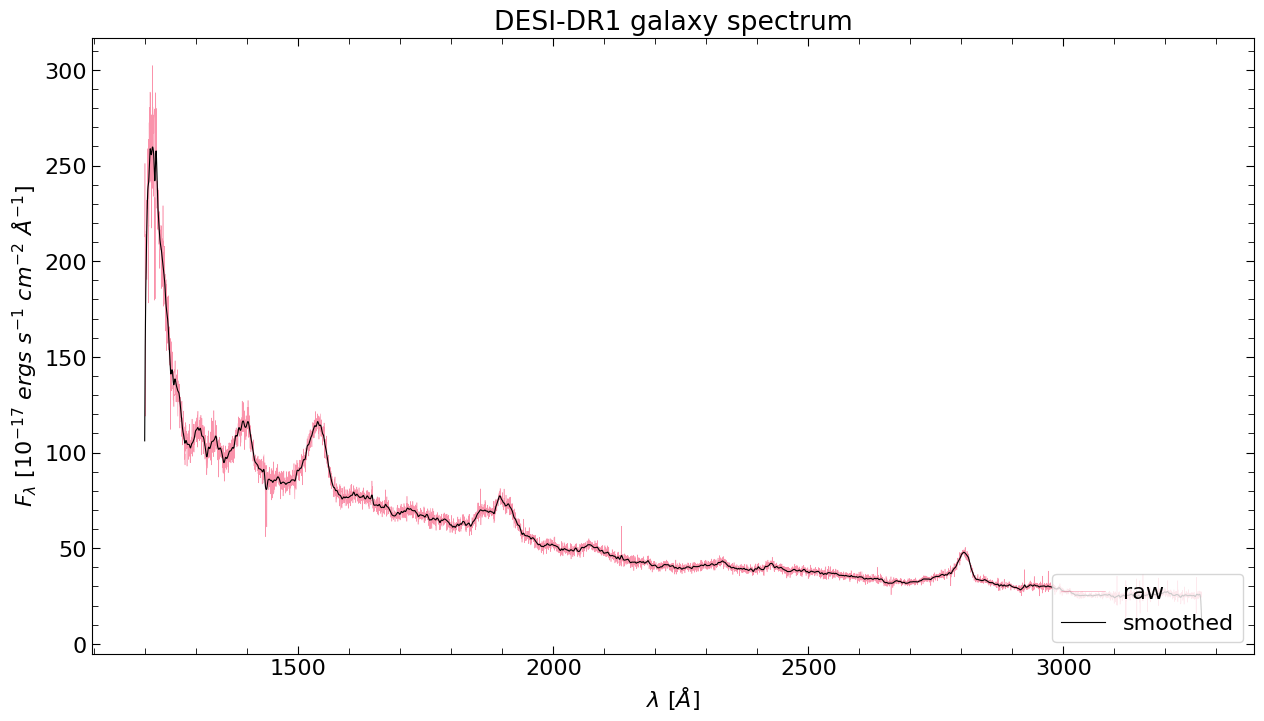

In [ ]:
idx = 2

lam = spectra[idx]["wavelength"].to_numpy()[0]
flux = spectra[idx]["flux"].to_numpy()[0]
z = spectra[idx]["redshift"].to_numpy()[0]

lam, flux = adjust_redshift(lam, flux, z)

plot_spectrum(lam, flux)